# MLN601 Assessment 1: Regression Analysis of UCI Red Wine Quality

- **Student:** Luis Guilherme de Barros Andrade Faria - A00187785
- **Subject Code:** MLN 601
- **Subject Name:** Machine Learning
- **Assessment No.:** 1
- **Title:** Regression Analysis of UCI Red Wine Quality
- **Lecturer:** Dr. Kamran Shaukat
- **Date:** June 2026

##### Extra details
| Field | Value |
|---|---|
| Dataset | UCI Wine Quality - red wine (Cortez et al., 2009) |
| Algorithm | Linear Regression (ordinary least squares) |
| Methodology | CRISP-DM |

This notebook follows the six CRISP-DM stages to build a transparent linear regression model that predicts red wine quality from physicochemical measurements. Wine quality is a subjective, ordinal sensory score, so the model is framed as an **interpretable decision-support baseline**, not a production replacement for expert tasting.

---

## 1. Business Understanding

### 1.1 Project objective
Wineries record objective chemical properties (acidity, sulphates, residual
sugar, alcohol, etc.) during production. This project tests whether those
measurements can predict the sensory **quality** score (0-10) recorded by
experts. The scope is the **UCI red wine dataset only**, to keep the target
population clear and avoid mixing the red and white wine distributions in a
short assessment.

The task is **supervised regression**: 11 physicochemical attributes as inputs
and `quality` as the dependent variable. A useful model would help a
quality-control team screen batches for likely low/high quality before final
expert tasting. Predictions are decision support, because quality is subjective
and influenced by factors not present in the data.

### 1.2 Evaluation criteria
| Criterion | Decision |
|---|---|
| Prediction error | MAE and RMSE, in quality-score units |
| Model fit | R^2 (variance explained on the held-out test set) |
| Baseline | Predict the training-set mean quality for every test row |
| Practical success | Beat the baseline and produce interpretable coefficients |
| Communication | Explain results in plain language for a QC stakeholder |

A perfect model is unrealistic: quality is judged by humans and the dataset
contains physicochemical variables only.

## 2. Data Understanding

### 2.1 Data acquisition
| Item | Detail |
|---|---|
| Source | UCI Machine Learning Repository (id 186) |
| Dataset page | https://archive.ics.uci.edu/dataset/186/wine+quality |
| Selected file | `winequality-red.csv` |
| Acquisition | Read the local CSV downloaded from UCI (URL fallback kept for reproducibility) |
| Separator | `;` |
| Expected shape | 1,599 rows x 12 columns |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [ ]:
from pathlib import Path

# Resolve project folders relative to the notebook location so the same
# notebook runs locally and on Colab/Azure without editing paths.
NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

UCI_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-red.csv"
)

candidates = [
    BASE_DIR / "dataset" / "winequality-red.csv",
    NB_DIR / "dataset" / "winequality-red.csv",
    NB_DIR / "winequality-red.csv",
]
local_path = next((p for p in candidates if p.exists()), None)

if local_path is not None:
    print("Loading local dataset:", local_path)
    df = pd.read_csv(local_path, sep=";")
else:
    print("Local file not found; loading from UCI URL:", UCI_URL)
    df = pd.read_csv(UCI_URL, sep=";")

print("Shape:", df.shape)
df.head()

Loading local dataset: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/dataset/winequality-red.csv
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### 2.2 Variable description
| Variable | Role | Type | Meaning / unit |
|---|---|---|---|
| fixed acidity | Feature | Continuous | Non-volatile acids (g/dm3) |
| volatile acidity | Feature | Continuous | Acetic acid (g/dm3) |
| citric acid | Feature | Continuous | Citric acid (g/dm3) |
| residual sugar | Feature | Continuous | Sugar after fermentation (g/dm3) |
| chlorides | Feature | Continuous | Salt content (g/dm3) |
| free sulfur dioxide | Feature | Continuous | Free SO2 (mg/dm3) |
| total sulfur dioxide | Feature | Continuous | Total SO2 (mg/dm3) |
| density | Feature | Continuous | Density (g/cm3) |
| pH | Feature | Continuous | Acidity/basicity |
| sulphates | Feature | Continuous | Sulphate additive (g/dm3) |
| alcohol | Feature | Continuous | Alcohol (% by volume) |
| quality | Target | Ordinal int | Sensory score 0-10 (median of >=3 experts) |

### 2.3 Data quality checks

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [ ]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nQuality value counts:")
print(df["quality"].value_counts().sort_index())

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate rows: 240

Quality value counts:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


**Interpretation.** All 12 columns are numeric, which suits regression. The
UCI documentation reports no missing values; the check above confirms this, so
no imputation is required. Duplicate rows are reported above; because the data
has no unique sample ID and identical physicochemical readings can legitimately
recur, the base model keeps them and a sensitivity note is added in Evaluation.
The quality distribution is concentrated on scores 5 and 6, with very few wines
at the extremes (3, 4, 8) - this imbalance limits how well a linear model can
learn the tails.

### 2.4 Exploratory analysis

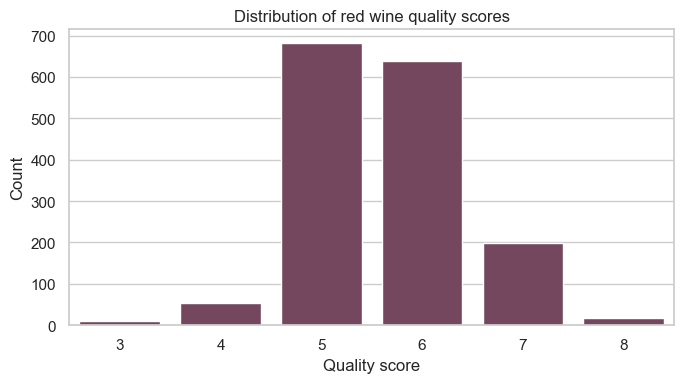

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(x="quality", data=df, color="#7b3f5f")
plt.title("Distribution of red wine quality scores")
plt.xlabel("Quality score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "quality_distribution.png", dpi=150)
plt.show()

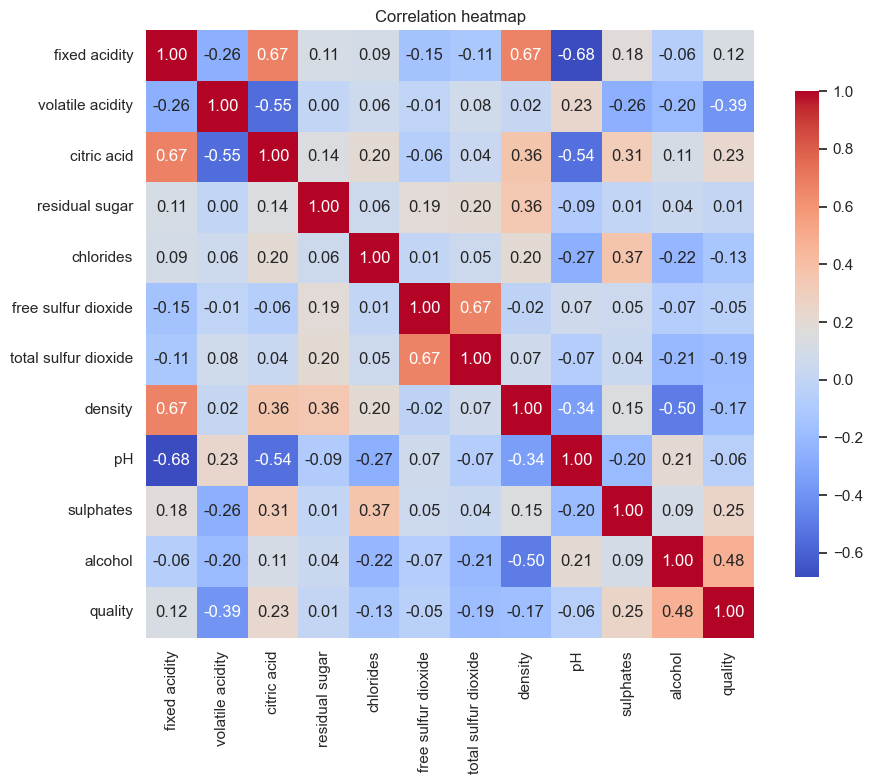

Correlation of each feature with quality (sorted):
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

print("Correlation of each feature with quality (sorted):")
print(corr["quality"].drop("quality").sort_values(ascending=False))

The brief requires a seaborn `pairplot`. The full 12-variable pairplot is dense
for a PDF, so a focused pairplot of `quality` plus the variables most correlated
with it (`alcohol`, `volatile acidity`, `sulphates`, `citric acid`, `density`)
is shown for readable interpretation. Uncomment the full pairplot to inspect all
relationships in the notebook.

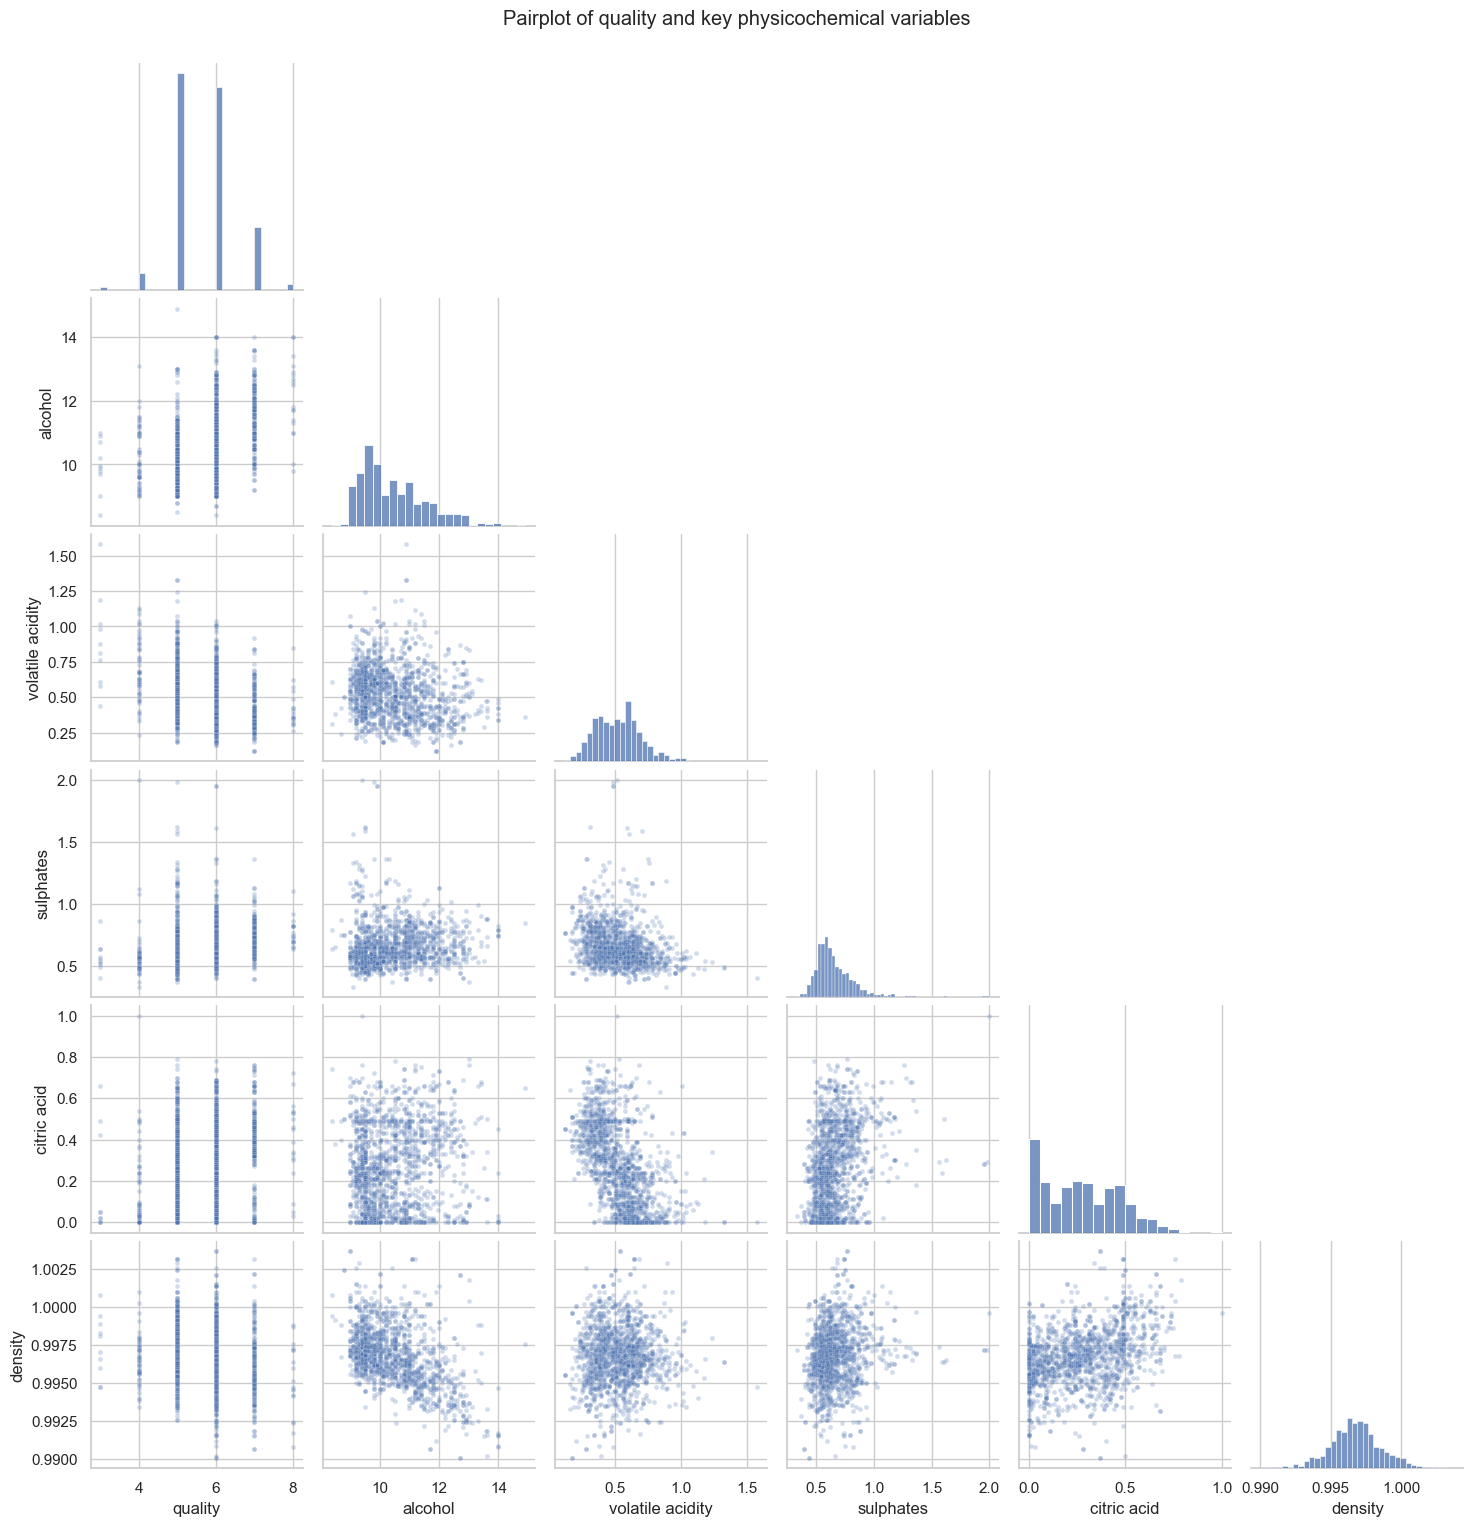

In [ ]:
pair_cols = ["quality", "alcohol", "volatile acidity",
             "sulphates", "citric acid", "density"]
pp = sns.pairplot(df[pair_cols], corner=True, diag_kind="hist",
                  plot_kws={"alpha": 0.25, "s": 12})
pp.figure.suptitle("Pairplot of quality and key physicochemical variables",
                   y=1.02)
pp.savefig(FIG_DIR / "pairplot.png", dpi=120)
plt.show()

# Full pairplot (all variables) - kept optional because it is large:
# sns.pairplot(df, corner=True, diag_kind="hist",
#              plot_kws={"alpha": 0.2, "s": 8})
# plt.show()

**Interpretation.** `alcohol` shows the clearest positive relationship with
quality; `volatile acidity` is the strongest negative; `sulphates` and
`citric acid` are weaker positives. Many relationships are noisy and far from a
clean line, which already signals that a linear model will be a useful but
imperfect baseline.

## 3. Data Preparation

### 3.1 Selection
The target is `quality`; the features are all 11 physicochemical columns. Red
wine is used alone (not combined with white) so the prediction targets one clear
population, which keeps interpretation simple in a 1,000-word report.

### 3.2 Cleaning and train/test split
No missing values were found, so no imputation is applied. The data is split
**before** fitting so the test set never influences training. Ordinary least
squares does not require feature scaling for prediction, so the base model uses
the raw features; standardised coefficients are discussed in Evaluation.

In [ ]:
target_col = "quality"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1279, 11) | Test: (320, 11)


## 4. Modelling

Linear regression is the required algorithm. It is transparent and fast, and its
coefficients estimate the change in predicted quality for a one-unit change in a
feature, holding the others constant. Key assumptions: approximately linear
relationships, independent errors, limited multicollinearity, and a continuous
target (here `quality` is treated as continuous despite being ordinal).

### 4.1 Baseline + base model

In [ ]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

# Baseline: predict the training-set mean for every test row.
baseline_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())

# Base model: linear regression on all 11 features.
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)
pred_all = model.predict(X_test)

results = pd.DataFrame([
    {"model": "Mean baseline", **regression_metrics(y_test, baseline_pred)},
    {"model": "Linear regression - all features",
     **regression_metrics(y_test, pred_all)},
])
results

,model,MAE,RMSE,R2
0,Mean baseline,0.685284,0.810654,-0.005592
1,Linear regression - all features,0.503530,0.624520,0.403180


### 4.2 Coefficients

In [ ]:
coefficients = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_,
}).sort_values("coefficient", ascending=False).reset_index(drop=True)

print("Intercept:", round(float(model.intercept_), 4))
coefficients

Intercept: 14.3551


,feature,coefficient
0,sulphates,0.841172
1,alcohol,0.281890
2,fixed acidity,0.023085
3,residual sugar,0.006564
4,free sulfur dioxide,0.005627
5,total sulfur dioxide,-0.003644
6,citric acid,-0.140821
7,pH,-0.393688
8,volatile acidity,-1.001304
9,chlorides,-1.806503


**Coefficient interpretation (read with caution).** The signs make sense:
`alcohol` (+0.28) and `sulphates` (+0.84) raise the predicted score, while
`volatile acidity` (-1.00) and `chlorides` (-1.81) lower it, which matches the
correlations seen earlier. The coefficients are not causal effect sizes, though:
`density` carries a very large weight (about -10.4) only because it is strongly
correlated with `alcohol` and `residual sugar`, so the model spreads weight across
collinear features. This multicollinearity is a known limitation of plain linear
regression and motivates the regularised models (Ridge/Lasso) suggested as future
work.

### 4.3 Revised run - selected features (optional)
A simpler model using only features whose absolute correlation with quality is
>= 0.10 tests whether comparable performance is achievable with fewer, easier to
explain variables.

In [ ]:
corr_abs = df.corr()["quality"].drop("quality").abs().sort_values(ascending=False)
selected_features = list(corr_abs[corr_abs >= 0.10].index)
print("Selected features:", selected_features)

X_sel = df[selected_features]
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
    X_sel, y, test_size=0.20, random_state=RANDOM_STATE
)
model_sel = LinearRegression(fit_intercept=True)
model_sel.fit(Xtr_s, ytr_s)
pred_sel = model_sel.predict(Xte_s)

results = pd.concat([
    results,
    pd.DataFrame([{
        "model": "Linear regression - selected features",
        **regression_metrics(yte_s, pred_sel),
    }]),
], ignore_index=True)
results

Selected features: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'total sulfur dioxide', 'density', 'chlorides', 'fixed acidity']


,model,MAE,RMSE,R2
0,Mean baseline,0.685284,0.810654,-0.005592
1,Linear regression - all features,0.503530,0.624520,0.403180
2,Linear regression - selected features,0.506212,0.626536,0.399320


## 5. Evaluation

### 5.1 Results
The linear regression clearly improves on the naive baseline. Predicting the
training-set mean for every wine gives an MAE of 0.685 and an RMSE of 0.811, with
an R^2 of about 0 by construction. The all-feature linear model lowers the MAE to
0.504 and the RMSE to 0.625 and reaches an R^2 of 0.40 on the held-out test set.
In practical terms, an RMSE of 0.63 means predictions are typically about 0.6 of a
quality point away from the score an expert assigned, and the R^2 shows the 11
physicochemical measurements explain roughly 40% of the variation in quality. The
remaining ~60% reflects the subjective, human nature of the target. The
selected-feature model (features with abs(corr) >= 0.10) performs almost
identically (RMSE 0.627, R^2 0.399), so a smaller, easier-to-explain model loses
essentially no accuracy here.

### 5.2 Residual and actual-vs-predicted diagnostics

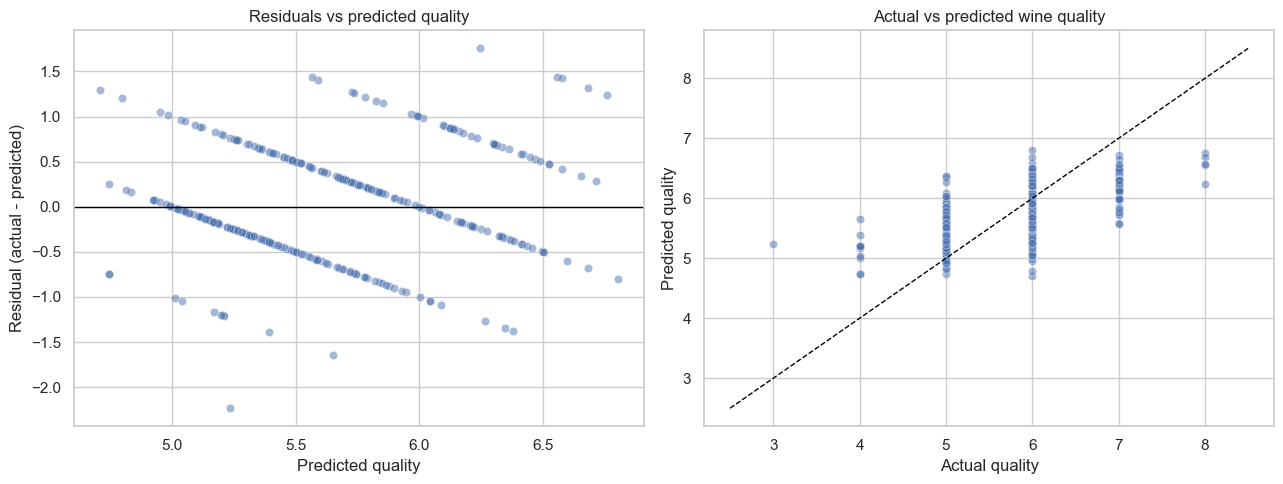

In [ ]:
residuals = y_test - pred_all

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=pred_all, y=residuals, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Predicted quality")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs predicted quality")

sns.scatterplot(x=y_test, y=pred_all, alpha=0.5, ax=axes[1])
lims = [y_test.min() - 0.5, y_test.max() + 0.5]
axes[1].plot(lims, lims, color="black", linewidth=1, linestyle="--")
axes[1].set_xlabel("Actual quality")
axes[1].set_ylabel("Predicted quality")
axes[1].set_title("Actual vs predicted wine quality")

plt.tight_layout()
plt.savefig(FIG_DIR / "residuals.png", dpi=150)
plt.show()

**Residual interpretation.** The residuals scatter fairly evenly around zero with
no strong funnel pattern, so the constant-variance assumption is broadly
reasonable. The actual-vs-predicted plot shows the model compresses its
predictions toward the middle of the scale and rarely predicts below 5 or above
6.5: it under-predicts the best wines and over-predicts the worst. This is
expected given how few training examples sit at the extreme quality scores.

### 5.3 Decision
> The model **does** meet the evaluation criteria: it **beats** the mean baseline
> on both MAE (0.504 vs 0.685) and RMSE (0.625 vs 0.811), reaches an R^2 of
> **0.40**, and yields interpretable chemistry-to-quality relationships. It should
> still be used only as a decision-support baseline, because the target is
> subjective and ordinal and the residual plot shows the relationships are not
> fully linear.

## 6. Deployment / Lessons Learned

No real deployment is required; this is the CRISP-DM reflection.

**Lessons learned**
- CRISP-DM forced the prediction goal to be defined before any code.
- Reading the documented UCI file (with a URL fallback) keeps the run reproducible.
- "Clean" numeric data still needed analysis of target imbalance and duplicates.
- Pairplot and correlation analysis explained *why* a linear model only fits
  moderately - several relationships are weak or non-linear.
- Linear regression is easy to explain, but likely underfits an ordinal,
  human-judged target.

**Future improvements**
| Improvement | Why it matters |
|---|---|
| Cross-validation | More stable estimate than a single split |
| Ridge/Lasso | Reduces coefficient instability from correlated features |
| Feature engineering | Ratios/transforms may capture chemistry effects better |
| Red vs white comparison | Tests whether wine types behave differently |
| Tree/ensemble models | May capture non-linear relationships |
| Deployment controls | Production use would need validation, monitoring, human review |

> A simple linear regression provides a reproducible, interpretable baseline for
> wine-quality prediction, but real business value depends on careful problem
> framing, transparent evaluation, and honest communication of limitations.

### Save metrics and coefficients (submission support files)

In [ ]:
results.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
coefficients.to_csv(OUTPUT_DIR / "coefficients.csv", index=False)
print("Saved:")
print(" -", OUTPUT_DIR / "model_metrics.csv")
print(" -", OUTPUT_DIR / "coefficients.csv")
print(" - figures in", FIG_DIR)

Saved:
 - /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/outputs/model_metrics.csv
 - /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/outputs/coefficients.csv
 - figures in /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/outputs/figures
